# Predictions Analysis
Bottlenecks, problem areas, and potential issues

In [2]:
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict, Counter

PREDICTIONS_PATH = '../submissions/predictions.json'
YAML_PATH = '../bottles.yaml'

with open(PREDICTIONS_PATH) as f:
    preds = json.load(f)

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

names = cfg['names']  # {0: 'ClassName', ...}
nc = cfg['nc']

df = pd.DataFrame(preds)
df['class_name'] = df['category_id'].map(names)
df['bbox_w'] = df['bbox'].apply(lambda b: b[2])
df['bbox_h'] = df['bbox'].apply(lambda b: b[3])
df['bbox_area'] = df['bbox_w'] * df['bbox_h']

print(f'Total predictions: {len(df)}')
print(f'Unique images: {df["image_id"].nunique()}')
print(f'Unique classes predicted: {df["category_id"].nunique()} / {nc}')
print(f'Score range: {df["score"].min():.3f} – {df["score"].max():.3f}')

Total predictions: 103177
Unique images: 481
Unique classes predicted: 352 / 369
Score range: 0.000 – 0.988


## 1. Missing Classes (never predicted)

In [3]:
predicted_ids = set(df['category_id'].unique())
all_ids = set(names.keys())
missing_ids = all_ids - predicted_ids

print(f'⚠️  Classes NEVER predicted: {len(missing_ids)} / {nc}')
for cid in sorted(missing_ids):
    print(f'  [{cid}] {names[cid]}')

⚠️  Classes NEVER predicted: 18 / 369
  [0] AbelAbuna_WHI_SinSco_BUT_700ml_00_00
  [82] BallFines_WHI_BleSco_KAR_SZKMIN_700ml_00_00
  [83] BallFines_WHI_BleSco_KAR_SZK_700ml_01_00
  [104] Ball_WHI_BleSco_21Yo_BUT_700ml_00_00
  [173] HavClubSelDeMae_RUM_BUT_700ml_02_00
  [176] HavClubSelDeMae_RUM_TUB_700ml_01_00
  [177] HavClub_RUM_3Yo_BUT_700ml_00_00
  [193] JamCaskmSto_WHI_BleIri_KAR_700ml_01_00
  [210] LilBlanc_LIK_BUT_750ml_02_00
  [212] LilRose_LIK_BUT_750ml_01_00
  [271] PanTadPrzep_WOD_Sma_BUT_500ml_00_00
  [309] TheGleIllicSti_WHI_SinSco_12Yo_BUT_700ml_00_00
  [324] TheGle_WHI_SinSco_15Yo_KAR_700ml_00_00
  [331] WybCytry_WOD_Sma_BUT_500ml_00_00
  [345] WybProst_WOD_Czy_BUT_700ml_01_00
  [346] WybProst_WOD_Czy_BUT_700ml_02_00
  [347] WybPszen_WOD_Czy_BUT_500ml_00_00
  [364] Wyb_WOD_Czy_BUT_1000ml_00_00


## 2. Score Distribution

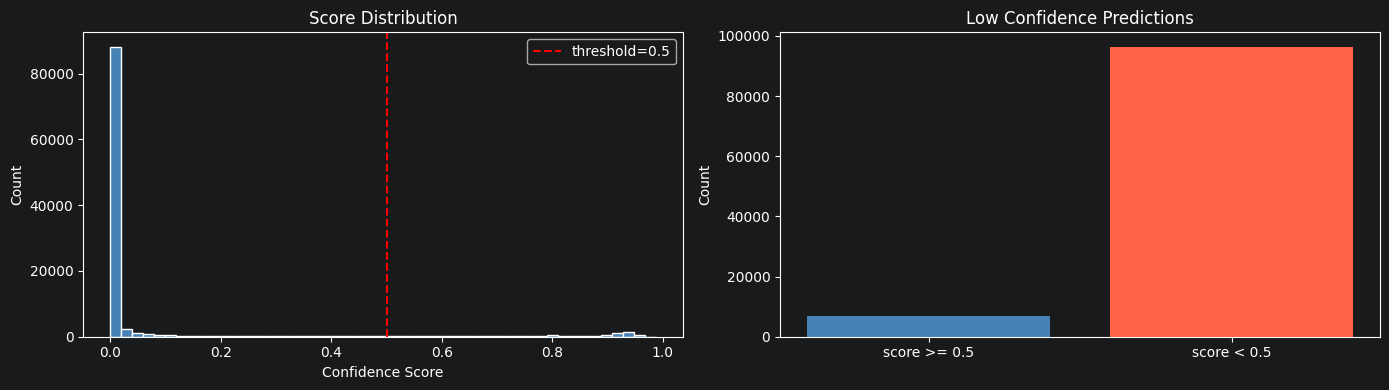

Low confidence predictions (< 0.5): 96366 (93.4%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['score'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

low_conf = df[df['score'] < 0.5]
axes[1].bar(['score >= 0.5', 'score < 0.5'],
            [len(df) - len(low_conf), len(low_conf)],
            color=['steelblue', 'tomato'])
axes[1].set_title('Low Confidence Predictions')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(f'Low confidence predictions (< 0.5): {len(low_conf)} ({100*len(low_conf)/len(df):.1f}%)')

## 3. Per-Class Prediction Frequency vs Score

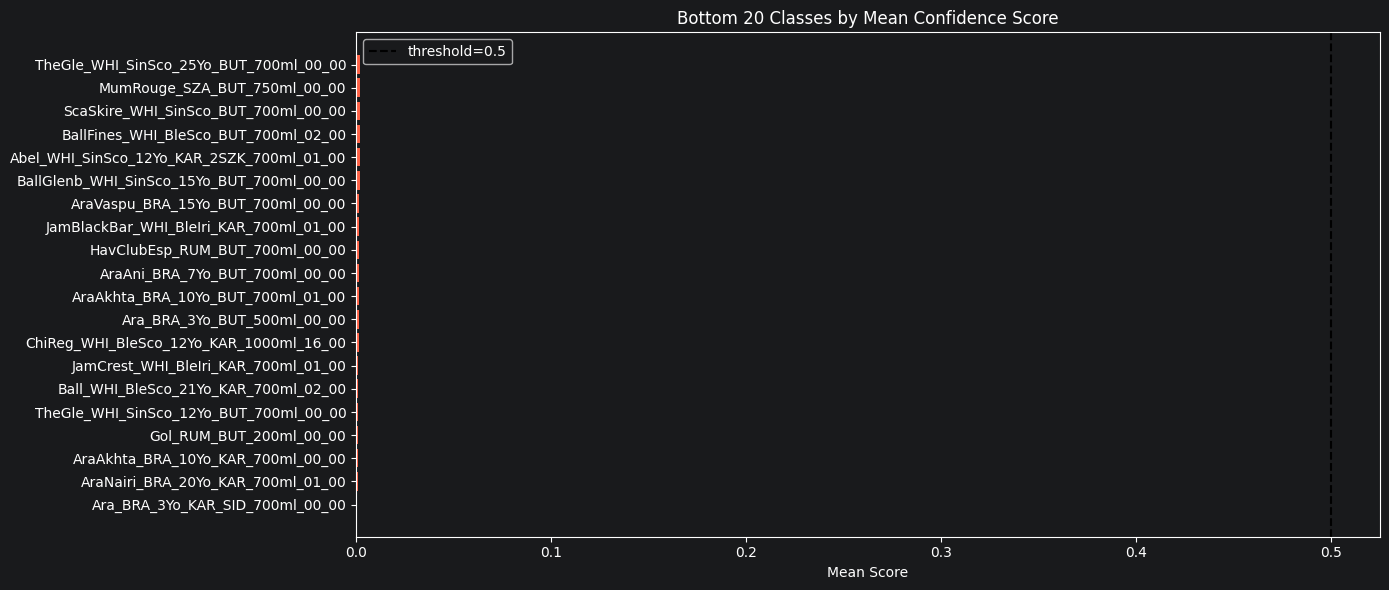

In [5]:
class_stats = df.groupby('category_id').agg(
    count=('score', 'count'),
    mean_score=('score', 'mean'),
    min_score=('score', 'min'),
    std_score=('score', 'std'),
).reset_index()
class_stats['class_name'] = class_stats['category_id'].map(names)
class_stats = class_stats.sort_values('mean_score')

# Bottom 20 classes by mean score
bottom20 = class_stats.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(bottom20['class_name'], bottom20['mean_score'], color='tomato')
ax.axvline(0.5, color='black', linestyle='--', label='threshold=0.5')
ax.set_title('Bottom 20 Classes by Mean Confidence Score')
ax.set_xlabel('Mean Score')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Overdetected Classes (potential false positives)

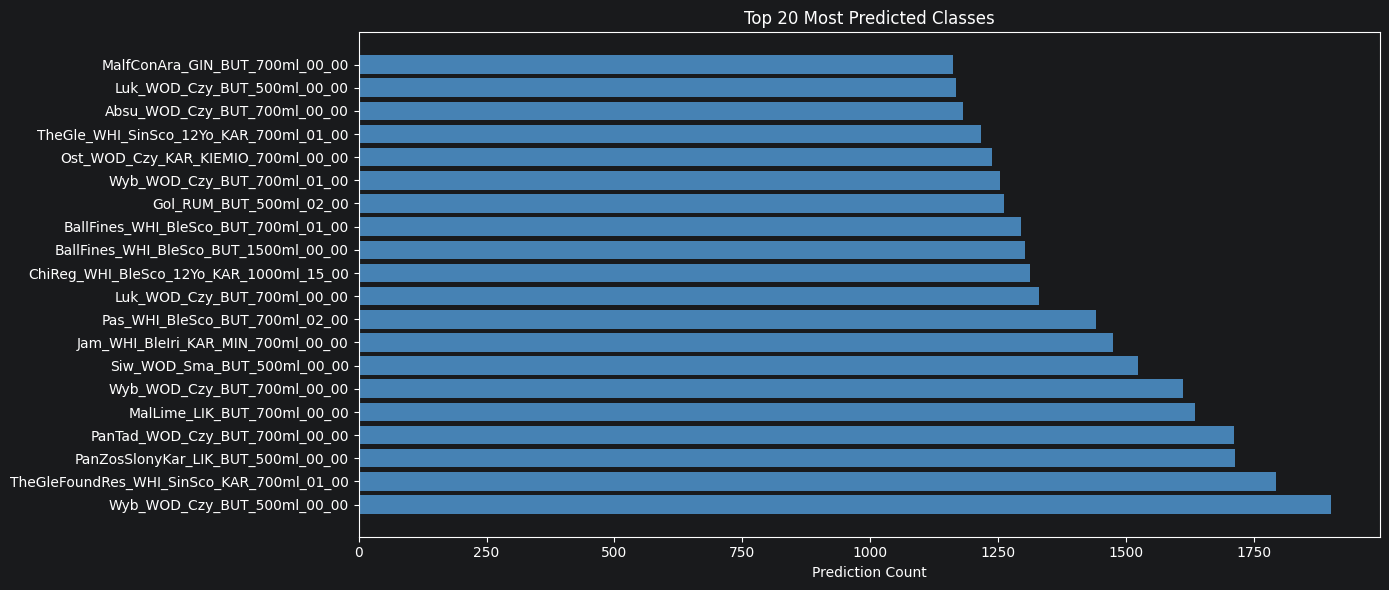

Potentially overdetected classes (>3x mean): 27
                               class_name  count  mean_score
TheGleFoundRes_WHI_SinSco_KAR_700ml_01_00   1792    0.022187
              Luk_WOD_Czy_BUT_500ml_00_00   1167    0.023203
                  Gol_RUM_BUT_500ml_00_00   1101    0.027838
                  Gol_RUM_BUT_500ml_02_00   1262    0.031324
   TheGle_WHI_SinSco_12Yo_KAR_700ml_01_00   1216    0.033228
              Wyb_WOD_Czy_BUT_500ml_00_00   1901    0.034184
              Siw_WOD_Sma_BUT_500ml_00_00   1523    0.056418
           Pas_WHI_BleSco_BUT_700ml_02_00   1441    0.058707
           MalfConAra_GIN_BUT_700ml_00_00   1161    0.060861
       PanZosSlonyKar_LIK_BUT_500ml_00_00   1713    0.065572
             BumCream_RUM_BUT_700ml_00_00    975    0.067469
           Pas_WHI_BleSco_BUT_500ml_02_00   1012    0.068038
              MalLime_LIK_BUT_700ml_00_00   1635    0.076481
           PanTad_WOD_Czy_BUT_700ml_00_00   1711    0.078624
  ChiReg_WHI_BleSco_12Yo_KAR_1000ml_1

In [6]:
top20_freq = class_stats.sort_values('count', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(top20_freq['class_name'], top20_freq['count'], color='steelblue')
ax.set_title('Top 20 Most Predicted Classes')
ax.set_xlabel('Prediction Count')
plt.tight_layout()
plt.show()

mean_count = class_stats['count'].mean()
overdetected = class_stats[class_stats['count'] > mean_count * 3]
print(f'Potentially overdetected classes (>3x mean): {len(overdetected)}')
print(overdetected[['class_name', 'count', 'mean_score']].to_string(index=False))

## 5. BBox Size Distribution (small object detection issues)

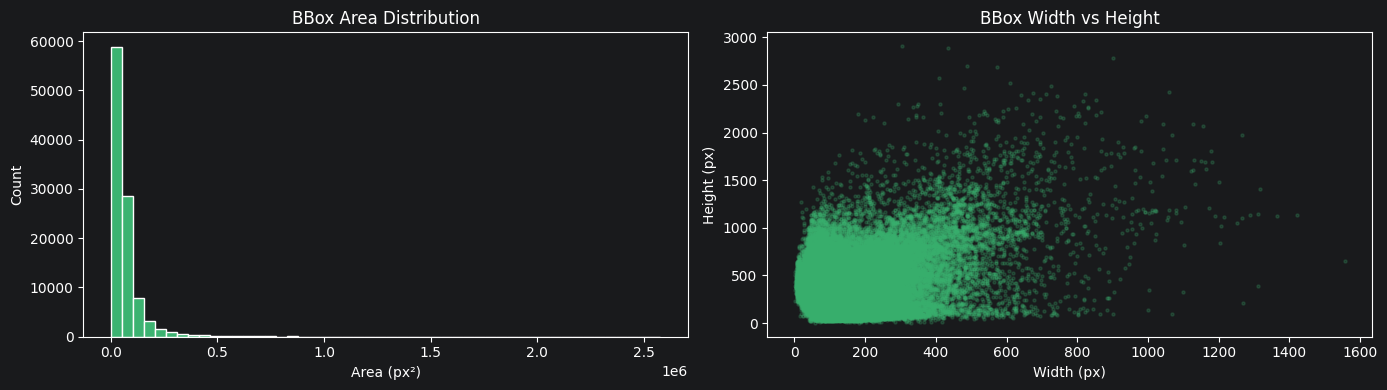

Small objects (area < 32²): 11 (0.0%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['bbox_area'], bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('BBox Area Distribution')
axes[0].set_xlabel('Area (px²)')
axes[0].set_ylabel('Count')

axes[1].scatter(df['bbox_w'], df['bbox_h'], alpha=0.2, s=5, color='mediumseagreen')
axes[1].set_title('BBox Width vs Height')
axes[1].set_xlabel('Width (px)')
axes[1].set_ylabel('Height (px)')

plt.tight_layout()
plt.show()

small = df[df['bbox_area'] < 32*32]
print(f'Small objects (area < 32²): {len(small)} ({100*len(small)/len(df):.1f}%)')

## 6. Predictions per Image (crowded scenes)

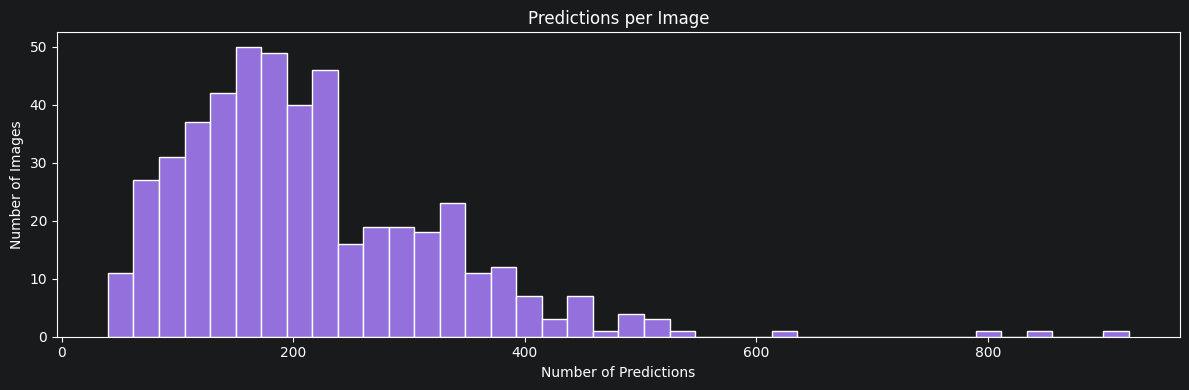

Mean predictions per image: 214.5
Max predictions per image:  922
Images with 0 predictions:  -112
Crowded images (>mean+2std): 18
image_id
2929    922
2997    849
2446    809
1560    616
1888    545
2471    522
1868    517
2943    509
2475    503
2687    502
dtype: int64


In [8]:
preds_per_img = df.groupby('image_id').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(preds_per_img, bins=40, color='mediumpurple', edgecolor='white')
ax.set_title('Predictions per Image')
ax.set_xlabel('Number of Predictions')
ax.set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

print(f'Mean predictions per image: {preds_per_img.mean():.1f}')
print(f'Max predictions per image:  {preds_per_img.max()}')
print(f'Images with 0 predictions:  {nc - len(preds_per_img)}')

crowded = preds_per_img[preds_per_img > preds_per_img.mean() + 2*preds_per_img.std()]
print(f'Crowded images (>mean+2std): {len(crowded)}')
print(crowded.sort_values(ascending=False).head(10))

## 7. Potential Issues Summary

In [9]:
issues = []

if len(missing_ids) > 0:
    issues.append(f'🔴 {len(missing_ids)} classes never predicted — few-shot or more data needed')

low_score_classes = class_stats[class_stats['mean_score'] < 0.5]
if len(low_score_classes) > 0:
    issues.append(f'🟠 {len(low_score_classes)} classes with mean score < 0.5 — confidence calibration needed')

if len(small) / len(df) > 0.1:
    issues.append(f'🟠 {100*len(small)/len(df):.1f}% small objects — consider larger imgsz')

high_std = class_stats[class_stats['std_score'].fillna(0) > 0.2]
if len(high_std) > 0:
    issues.append(f'🟡 {len(high_std)} classes with high score variance (std > 0.2) — unstable predictions')

if len(overdetected) > 0:
    issues.append(f'🟡 {len(overdetected)} overdetected classes — possible false positives, check NMS/WBF threshold')

predicted_ratio = len(predicted_ids) / nc
if predicted_ratio < 0.8:
    issues.append(f'🔴 Only {100*predicted_ratio:.1f}% of classes predicted — model underperforms on rare classes')

print('='*60)
print('ISSUES SUMMARY')
print('='*60)
for issue in issues:
    print(issue)
if not issues:
    print('✅ No major issues detected')
print('='*60)
print(f'\nTotal predictions:     {len(df)}')
print(f'Classes predicted:     {len(predicted_ids)} / {nc}')
print(f'Mean score:            {df["score"].mean():.3f}')
print(f'Low conf preds (<0.5): {len(low_conf)}')
print(f'Small objects:         {len(small)}')

ISSUES SUMMARY
🔴 18 classes never predicted — few-shot or more data needed
🟠 352 classes with mean score < 0.5 — confidence calibration needed
🟡 104 classes with high score variance (std > 0.2) — unstable predictions
🟡 27 overdetected classes — possible false positives, check NMS/WBF threshold

Total predictions:     103177
Classes predicted:     352 / 369
Mean score:            0.067
Low conf preds (<0.5): 96366
Small objects:         11
